# Practice lab : Logistic Regression

# 1 - Import packages
- [numpy](https://www.numpy.org) is the fundamental package for working with matrices in Python.
- [matplotlib](https://matplotlib.org) is a famous library to plot graphs in Python.
- [pandas](https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.html) is used for data manipulation and analysis (in this lab used it to load the dataset)
  

In [400]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import math
import copy

# 2.1  Problem statement - part 1
Suppose that you are the administrator of a university department and you want to determine each applicant’s chance of admission based on their results on two exams. 
* You have historical data from previous applicants that you can use as a training set for logistic regression. 
* For each training example, you have the applicant’s scores on two exams and the admissions decision. 
* Your task is to build a classification model that estimates an applicant’s probability of admission based on the scores from those two exams.

### 2.2 Loading and visualizing the data

You will start by loading the dataset for this task. 

  - `X_train` contains exam scores on two exams for a student
  - `y_train` is the admission decision 
      - `y_train = 1` if the student was admitted 
      - `y_train = 0` if the student was not admitted 
  - Both `X_train` and `y_train` are numpy arrays.

In [401]:
df = pd.read_csv(r"E:\SALEH\Data\ex2data1.txt",names=['exam_scores1',"exam_scores2","admission decision"])

In [402]:
df.head()

,exam_scores1,exam_scores2,admission decision
0,34.623660,78.024693,0
1,30.286711,43.894998,0
2,35.847409,72.902198,0
3,60.182599,86.308552,1
4,79.032736,75.344376,1


In [403]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 3 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   exam_scores1        100 non-null    float64
 1   exam_scores2        100 non-null    float64
 2   admission decision  100 non-null    int64  
dtypes: float64(2), int64(1)
memory usage: 2.5 KB


In [404]:
X_train = df.drop("admission decision",axis=1)
X_train= np.array(X_train)

print(f"The shape of X_train : {X_train.shape}")
print(f"type of X_train : {type(X_train)}")
print(f"Number of training EX : {len(X_train)}")
print(f"First five element of X_train : \n {X_train[:5]}")


The shape of X_train : (100, 2)
type of X_train : <class 'numpy.ndarray'>
Number of training EX : 100
First five element of X_train : 
 [[34.62365962 78.02469282]
 [30.28671077 43.89499752]
 [35.84740877 72.90219803]
 [60.18259939 86.3085521 ]
 [79.03273605 75.34437644]]


In [405]:
y_train = df['admission decision']
y_train = np.array(y_train)


print(f"The shape of y_train : {y_train.shape}")
print(f"type of X_train : {type(y_train)}")
print(f"Number of training EX : {len(y_train)}")
print(f"First five element of y_train : {y_train[:5]}")

The shape of y_train : (100,)
type of X_train : <class 'numpy.ndarray'>
Number of training EX : 100
First five element of y_train : [0 0 0 1 1]


In [406]:
print ('The shape of X_train is: ' + str(X_train.shape))
print ('The shape of y_train is: ' + str(y_train.shape))
print ('We have m = %d training examples' % (len(y_train)))

The shape of X_train is: (100, 2)
The shape of y_train is: (100,)
We have m = 100 training examples


# visualizing the data

In [407]:
admitted = df[df['admission decision'] == 1]
not_admitted = df[df['admission decision'] == 0]

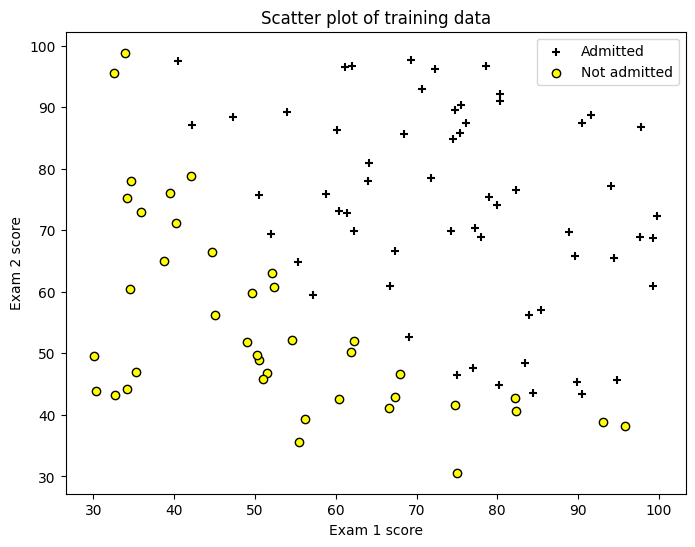

In [408]:
plt.figure(figsize=(8,6))
plt.scatter(admitted['exam_scores1'], admitted['exam_scores2'], c='black', marker='+', label='Admitted') # admitted

plt.scatter(not_admitted['exam_scores1'], not_admitted['exam_scores2'], c='yellow', edgecolors='k', marker='o', label='Not admitted') # not


plt.xlabel('Exam 1 score')
plt.ylabel('Exam 2 score')
plt.legend()
plt.title('Scatter plot of training data')
plt.show()

---
# Goal : build a logistic regression model to fit this data

Recall that for logistic regression, the model is represented as

$$ f_{\mathbf{w},b}(x) = g(\mathbf{w}\cdot \mathbf{x} + b)$$
where function $g$ is the sigmoid function. The sigmoid function is defined as:

$$g(z) = \frac{1}{1+e^{-z}}$$

Let's implement the sigmoid function first, so it can be used by the rest of this assignment.


In [409]:
def sigmoid(z):
    return 1/(1+np.exp(-z))


# run the sigmoid

value = 0

print(f"sigmoid({value}) = {sigmoid(value)}")

print (f"sigmoid([ -1, 0, 1, 2]) = {sigmoid(np.array([-1,0,1,2]))}")

sigmoid(0) = 0.5
sigmoid([ -1, 0, 1, 2]) = [0.26894142 0.5        0.73105858 0.88079708]


### 2.4 Cost function for logistic regression

In this section, you will implement the cost function for logistic regression.

Recall that for logistic regression, the cost function is of the form 

$$ J(\mathbf{w},b) = \frac{1}{m}\sum_{i=0}^{m-1} \left[ loss(f_{\mathbf{w},b}(\mathbf{x}^{(i)}), y^{(i)}) \right] \tag{1}$$

where
* m is the number of training examples in the dataset

  
* $loss(f_{\mathbf{w},b}(\mathbf{x}^{(i)}), y^{(i)})$ is the cost for a single data point, which is - 

    $$loss(f_{\mathbf{w},b}(\mathbf{x}^{(i)}), y^{(i)}) = (-y^{(i)} \log\left(f_{\mathbf{w},b}\left( \mathbf{x}^{(i)} \right) \right) - \left( 1 - y^{(i)}\right) \log \left( 1 - f_{\mathbf{w},b}\left( \mathbf{x}^{(i)} \right) \right) \tag{2}$$
    
    
*  $f_{\mathbf{w},b}(\mathbf{x}^{(i)})$ is the model's prediction, while $y^{(i)}$, which is the actual label

*  $f_{\mathbf{w},b}(\mathbf{x}^{(i)}) = g(\mathbf{w} \cdot \mathbf{x^{(i)}} + b)$ where function $g$ is the sigmoid function.
    * It might be helpful to first calculate an intermediate variable $z_{\mathbf{w},b}(\mathbf{x}^{(i)}) = \mathbf{w} \cdot \mathbf{x^{(i)}} + b = w_0x^{(i)}_0 + ... + w_{n-1}x^{(i)}_{n-1} + b$ where $n$ is the number of features, before calculating $f_{\mathbf{w},b}(\mathbf{x}^{(i)}) = g(z_{\mathbf{w},b}(\mathbf{x}^{(i)}))$

Note:
* As you are doing this, remember that the variables `X_train` and `y_train` are not scalar values but matrices of shape ($m, n$) and ($𝑚$,1) respectively, where  $𝑛$ is the number of features and $𝑚$ is the number of training examples.
* You can use the sigmoid function that you implemented above for this part.

If you get stuck, you can check out the hints presented after the cell below to help you with the implementation.

In [410]:
import numpy as np

def sigmoid(z):
    return 1 / (1 + np.exp(-z))

def compute_logistic_cost(x, y, w, b, *argv):
    m, n = x.shape
    cost = 0.0
    for i in range(m):
        f_wb = np.dot(x[i], w) + b
        y_hat = sigmoid(f_wb)
        
        cost += -y[i] * np.log(y_hat) - (1 - y[i]) * np.log(1 - y_hat)
    
    cost = cost / m
    return cost


In [411]:
m, n = X_train.shape

# Compute and display cost with w and b initialized to zeros
initial_w = np.zeros(n)
initial_b = 0.
cost = compute_logistic_cost(X_train, y_train, initial_w, initial_b)
print('Cost at initial w and b (zeros): {:.3f}'.format(cost))

Cost at initial w and b (zeros): 0.693


---

### 2.5 Gradient for logistic regression

In this section, you will implement the gradient for logistic regression.

Recall that the gradient descent algorithm is:

$$\begin{align*}& \text{repeat until convergence:} \; \lbrace \newline \; & b := b -  \alpha \frac{\partial J(\mathbf{w},b)}{\partial b} \newline       \; & w_j := w_j -  \alpha \frac{\partial J(\mathbf{w},b)}{\partial w_j} \tag{1}  \; & \text{for j := 0..n-1}\newline & \rbrace\end{align*}$$

where, parameters $b$, $w_j$ are all updated simultaniously

 `compute_gradient` function to compute $\frac{\partial J(\mathbf{w},b)}{\partial w}$, $\frac{\partial J(\mathbf{w},b)}{\partial b}$ from equations (2) and (3) below.

$$
\frac{\partial J(\mathbf{w},b)}{\partial b}  = \frac{1}{m} \sum\limits_{i = 0}^{m-1} (f_{\mathbf{w},b}(\mathbf{x}^{(i)}) - \mathbf{y}^{(i)}) \tag{2}
$$
$$
\frac{\partial J(\mathbf{w},b)}{\partial w_j}  = \frac{1}{m} \sum\limits_{i = 0}^{m-1} (f_{\mathbf{w},b}(\mathbf{x}^{(i)}) - \mathbf{y}^{(i)})x_{j}^{(i)} \tag{3}
$$
* m is the number of training examples in the dataset

    
*  $f_{\mathbf{w},b}(x^{(i)})$ is the model's prediction, while $y^{(i)}$ is the actual label


- **Note**: While this gradient looks identical to the linear regression gradient, the formula is actually different because linear and logistic regression have different definitions of $f_{\mathbf{w},b}(x)$.

As before, you can use the sigmoid function that you implemented above and if you get stuck, you can check out the hints presented after the cell below to help you with the implementation.

In [412]:
import numpy as np

def compute_gradient_LG(x, y, w, b, *argv):
    m, n = x.shape
    dj_dw = np.zeros(n)
    dj_db = 0.0

    for i in range(m):
        z = np.dot(x[i], w) + b
        y_hat = sigmoid(z)
        error = y_hat - y[i]
        dj_db += error
        for j in range(n):
            dj_dw[j] += error * x[i, j]

    dj_db /= m
    dj_dw /= m

    return dj_db, dj_dw


In [413]:
# Compute and display gradient with w and b initialized to zeros
initial_w = np.zeros(n)
initial_b = 0.

dj_db, dj_dw = compute_gradient_LG(X_train, y_train, initial_w, initial_b)
print(f'dj_db at initial w and b (zeros):{dj_db}' )
print(f'dj_dw at initial w and b (zeros):{dj_dw.tolist()}' )

dj_db at initial w and b (zeros):-0.1
dj_dw at initial w and b (zeros):[-12.00921658929115, -11.262842205513591]



### 2.6 Learning parameters using gradient descent 

- A good way to verify that gradient descent is working correctly is to look
at the value of $J(\mathbf{w},b)$ and check that it is decreasing with each step. 

- Assuming you have implemented the gradient and computed the cost correctly, your value of $J(\mathbf{w},b)$ should never increase, and should converge to a steady value by the end of the algorithm.

In [414]:
def gradient_descent(X, y, w_in, b_in, alpha, num_iters): 
   
    # An array to store cost J and w's at each iteration primarily for graphing later
    J_history = []
    w = copy.deepcopy(w_in)  #avoid modifying global w within function
    b = b_in
    
    for i in range(num_iters):
        # Calculate the gradient and update the parameters
        dj_db, dj_dw = compute_gradient_LG(X, y, w, b,)   

        # Update Parameters using w, b, alpha and gradient
        w = w - alpha * dj_dw               
        b = b - alpha * dj_db               
      
        # Save cost J at each iteration
        if i<100000:      # prevent resource exhaustion 
            J_history.append( compute_logistic_cost(X, y, w, b,lambda_) )

        # Print cost every at intervals 10 times or as many iterations if < 10
        if i % math.ceil(num_iters/10)==0:
            print(f"Iteration {i:4d}: Cost {float(J_history[-1]):8.2f}")
        
    return w, b, J_history         #return final w,b and J history for graphing


In [415]:
np.random.seed(1)
initial_w = 0.01 * (np.random.rand(2) - 0.5)
initial_b = -8

# Some gradient descent settings
iterations = 10000
alpha = 0.001

w,b, J_history= gradient_descent(X_train ,y_train, initial_w, initial_b, alpha, iterations)

Iteration    0: Cost     0.96
Iteration 1000: Cost     0.31
Iteration 2000: Cost     0.30
Iteration 3000: Cost     0.30
Iteration 4000: Cost     0.30
Iteration 5000: Cost     0.30
Iteration 6000: Cost     0.30
Iteration 7000: Cost     0.30
Iteration 8000: Cost     0.30
Iteration 9000: Cost     0.30


# Prediction and plotting

In [416]:
def predict(X, w, b): 
    """
    Predict binary labels (0 or 1) using logistic regression parameters w and b.
    """
    m, n = X.shape   
    p = np.zeros(m)

    for i in range(m):   
        z_wb = np.dot(X[i], w) + b          # Linear 
        f_wb = sigmoid(z_wb)                # Sigmoid output
        p[i] = 1 if f_wb >= 0.5 else 0      # Threshold at 0.5

    return p


In [417]:
# Test your predict code
np.random.seed(1)
tmp_w = np.random.randn(2)
tmp_b = 0.3    
tmp_X = np.random.randn(4, 2) - 0.5

tmp_p = predict(tmp_X, tmp_w, tmp_b)
print(f'Output of predict: shape {tmp_p.shape}, value {tmp_p}')


Output of predict: shape (4,), value [0. 1. 1. 1.]


In [418]:
p = predict(X_train, w,b)
print('Train Accuracy: %f'%(np.mean(p == y_train) * 100))

Train Accuracy: 92.000000


---

<a name="3"></a>
## 3 - Regularized Logistic Regression
### 3.1 Problem Statement - part2

Suppose you are the product manager of the factory and you have the test results for some microchips on two different tests. 
- From these two tests, you would like to determine whether the microchips should be accepted or rejected. 
- To help you make the decision, you have a dataset of test results on past microchips, from which you can build a logistic regression model.

<a name="3.2"></a>
### 3.2 Loading and visualizing the data

Similar to previous parts of this exercise, let's start by loading the dataset for this task and visualizing it. 

  - `X_train` contains the test results for the microchips from two tests
  - `y_train` contains the results of the QA  
      - `y_train = 1` if the microchip was accepted 
      - `y_train = 0` if the microchip was rejected 
  - Both `X_train` and `y_train` are numpy arrays.

In [419]:
df = pd.read_csv(r"E:\SALEH\Data\ex2data2.txt",names=['test1','test2','result'])

In [420]:
df.head()

,test1,test2,result
0,0.051267,0.69956,1
1,-0.092742,0.68494,1
2,-0.213710,0.69225,1
3,-0.375000,0.50219,1
4,-0.513250,0.46564,1


In [421]:
X_train = df.drop("result",axis=1)
X_train= np.array(X_train)

print(f"The shape of X_train : {X_train.shape}")
print(f"type of X_train : {type(X_train)}")
print(f"Number of training EX : {len(X_train)}")
print(f"First five element of X_train : \n {X_train[:5]}")


The shape of X_train : (118, 2)
type of X_train : <class 'numpy.ndarray'>
Number of training EX : 118
First five element of X_train : 
 [[ 0.051267  0.69956 ]
 [-0.092742  0.68494 ]
 [-0.21371   0.69225 ]
 [-0.375     0.50219 ]
 [-0.51325   0.46564 ]]


In [422]:
y_train = df['result']
y_train = np.array(y_train)


print(f"The shape of y_train : {y_train.shape}")
print(f"type of X_train : {type(y_train)}")
print(f"Number of training EX : {len(y_train)}")
print(f"First five element of y_train : {y_train[:5]}")

The shape of y_train : (118,)
type of X_train : <class 'numpy.ndarray'>
Number of training EX : 118
First five element of y_train : [1 1 1 1 1]


#### Visualizing the data data

In [423]:
accepted = df[df['result'] == 1]
rejected = df[df['result'] == 0]

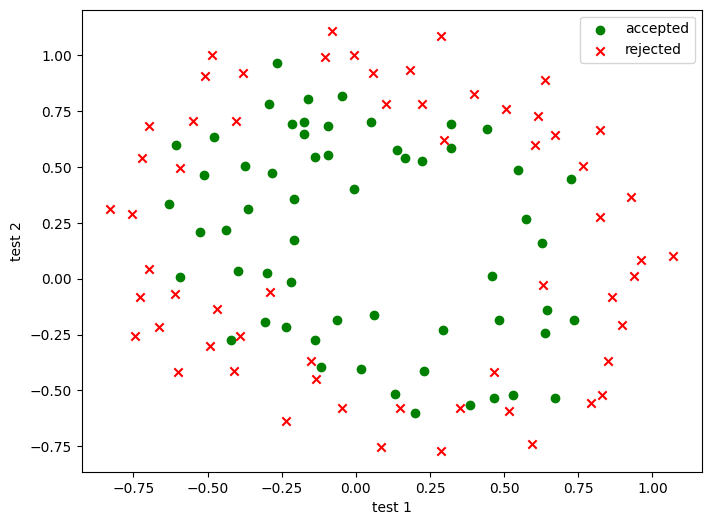

In [424]:
plt.figure(figsize=(8,6))
plt.scatter(accepted['test1'],accepted['test2'],c='green',marker= 'o' ,label = 'accepted' )
plt.scatter(rejected['test1'],rejected['test2'],c='red',marker= 'x',label = 'rejected' )

plt.xlabel("test 1")
plt.ylabel('test 2')
plt.legend()
plt.show()

### 3.4 Cost function for regularized logistic regression

In this part, you will implement the cost function for regularized logistic regression.

Recall that for regularized logistic regression, the cost function is of the form
$$J(\mathbf{w},b) = \frac{1}{m}  \sum_{i=0}^{m-1} \left[ -y^{(i)} \log\left(f_{\mathbf{w},b}\left( \mathbf{x}^{(i)} \right) \right) - \left( 1 - y^{(i)}\right) \log \left( 1 - f_{\mathbf{w},b}\left( \mathbf{x}^{(i)} \right) \right) \right] + \frac{\lambda}{2m}  \sum_{j=0}^{n-1} w_j^2$$

Compare this to the cost function without regularization (which you implemented above), which is of the form 

$$ J(\mathbf{w}.b) = \frac{1}{m}\sum_{i=0}^{m-1} \left[ (-y^{(i)} \log\left(f_{\mathbf{w},b}\left( \mathbf{x}^{(i)} \right) \right) - \left( 1 - y^{(i)}\right) \log \left( 1 - f_{\mathbf{w},b}\left( \mathbf{x}^{(i)} \right) \right)\right]$$

The difference is the regularization term, which is $$\frac{\lambda}{2m}  \sum_{j=0}^{n-1} w_j^2$$ 
Note that the $b$ parameter is not regularized.

In [425]:
# UNQ_C5
def compute_cost_reg(x, y, w, b, lambda_ = 1):
    
    m, n = x.shape
    
    # Calls the compute_cost function that you implemented above
    cost_without_reg = compute_logistic_cost(x, y, w, b) 
    print(f"cost without regularization = {cost_without_reg}")
    # You need to calculate this value
    reg_cost = 0.
    
   
    
    for j in range(n):
        reg_cost+= (w[j]**2)
        
    reg_cost = (lambda_ / (2*m)) * reg_cost
    
    
    # Add the regularization cost to get the total cost
    total_cost = cost_without_reg + reg_cost

    return total_cost

In [426]:

np.random.seed(1)
initial_w = np.random.rand(X_train.shape[1]) 
initial_b = 0.5
lambda_ = 0.5
cost = compute_cost_reg(X_train, y_train, initial_w, initial_b, lambda_)

print("Regularized cost :", cost)


cost without regularization = 0.7757939392610371
Regularized cost : 0.7772616823293822



### 3.5 Gradient for regularized logistic regression


The gradient of the regularized cost function has two components. The first, $\frac{\partial J(\mathbf{w},b)}{\partial b}$ is a scalar, the other is a vector with the same shape as the parameters $\mathbf{w}$, where the $j^\mathrm{th}$ element is defined as follows:

$$\frac{\partial J(\mathbf{w},b)}{\partial b} = \frac{1}{m}  \sum_{i=0}^{m-1} (f_{\mathbf{w},b}(\mathbf{x}^{(i)}) - y^{(i)})  $$

$$\frac{\partial J(\mathbf{w},b)}{\partial w_j} = \left( \frac{1}{m}  \sum_{i=0}^{m-1} (f_{\mathbf{w},b}(\mathbf{x}^{(i)}) - y^{(i)}) x_j^{(i)} \right) + \frac{\lambda}{m} w_j  \quad\, \mbox{for $j=0...(n-1)$}$$

Compare this to the gradient of the cost function without regularization (which you implemented above), which is of the form 
$$
\frac{\partial J(\mathbf{w},b)}{\partial b}  = \frac{1}{m} \sum\limits_{i = 0}^{m-1} (f_{\mathbf{w},b}(\mathbf{x}^{(i)}) - \mathbf{y}^{(i)}) \tag{2}
$$
$$
\frac{\partial J(\mathbf{w},b)}{\partial w_j}  = \frac{1}{m} \sum\limits_{i = 0}^{m-1} (f_{\mathbf{w},b}(\mathbf{x}^{(i)}) - \mathbf{y}^{(i)})x_{j}^{(i)} \tag{3}
$$


As you can see,$\frac{\partial J(\mathbf{w},b)}{\partial b}$ is the same, the difference is the following term in $\frac{\partial J(\mathbf{w},b)}{\partial w}$, which is $$\frac{\lambda}{m} w_j  \quad\, \mbox{for $j=0...(n-1)$}$$ 





In [427]:
def sigmoid(z): 
    return 1 / (1 + np.exp(-z))

def compute_gradient_LG(x, y, w, b, lambda_):
    m, n = x.shape
    dj_dw = np.zeros(n)
    dj_db = 0.0

    for i in range(m):
        error = np.dot(x[i], w) + b - y[i]  # dot returns scalar 
        dj_db += error
        for j in range(n):
            dj_dw[j] += error * x[i, j]
            
    dj_dw = dj_dw / m
    dj_db = dj_db / m

    # Add L2 regularization only to dj_dw
    for j in range(n):
        dj_dw[j] += (lambda_ / m) * w[j]

    return dj_dw, dj_db



In [428]:

np.random.seed(1) 
initial_w  = np.random.rand(X_train.shape[1])
initial_b = 0.5
 
lambda_ = 0.5
dj_dw,dj_db = compute_gradient_LG(X_train, y_train, initial_w, initial_b, lambda_)

print(f"dj_db: {dj_db}", )
print(f"First few elements of regularized dj_dw:\n {dj_dw.tolist()}", )


dj_db: 0.16321112446578634
First few elements of regularized dj_dw:
 [0.10545150779894907, 0.20959158988622992]


### 3.6 Learning parameters using gradient descent

Similar to the previous parts, you will use your gradient descent function implemented above to learn the optimal parameters $w$,$b$. 

**Note**

The code block below takes quite a while to run, especially with a non-vectorized version. You can reduce the `iterations` to test your implementation and iterate faster. If you have time later, run for 100,000 iterations to see better results.

In [429]:
def gradient_descent_REG(X, y, w_in, b_in, alpha, num_iters, lambda_): 
    J_history = []
    w = w_in.copy()  # Avoid modifying original weights
    b = b_in
    
    for i in range(num_iters):
        # Get gradients
        dj_dw, dj_db = compute_gradient_LG(X, y, w, b, lambda_)

        # Update weights
        w = w - alpha * dj_dw
        b = b - alpha * dj_db

        # Track cost
        if i < 100000:
            J_history.append(compute_logistic_cost(X, y, w, b, lambda_))

        # Print progress
        if i % math.ceil(num_iters / 10) == 0:
            print(f"Iteration {i:4d}: Cost {J_history[-1]:.4f}")

    return w, b, J_history


In [430]:
np.random.seed(1)
initial_w = np.random.rand(X_train.shape[1])-0.5
initial_b = 1.

lambda_ = 0.01    

# Some gradient descent settings
iterations = 10000
alpha = 0.01

w,b, J_history = gradient_descent_REG(X_train, y_train, initial_w, initial_b,alpha, iterations, lambda_)

Iteration    0: Cost 0.8287
Iteration 1000: Cost 0.7259
Iteration 2000: Cost 0.7260
Iteration 3000: Cost 0.7260
Iteration 4000: Cost 0.7260
Iteration 5000: Cost 0.7260
Iteration 6000: Cost 0.7260
Iteration 7000: Cost 0.7260
Iteration 8000: Cost 0.7260
Iteration 9000: Cost 0.7260


| Week | Description                      | Slides 📄                          | Notebooks 📓                       |
|------|----------------------------------|------------------------------------|-----------------------------------|
| 3    | classification             | [Week 3 Slides](slides/week1.pdf) | [Week 3 Notebooks](notebooks/week1.ipynb) |


# Logistic Regression 

is a supervised learning algorithm used for binary classification,It predicts the probability that an input belongs to class 1 or 0. 

- It starts with our linear regression model 
  - $z = \mathbf{w} \cdot  \mathbf{x}^{(i)} + b$ 


- Then applies the sigmoid function to squash the output between 0 and 1
  - $σ(z) = \frac{1}{1+e^{-z}}\tag{1}$
  
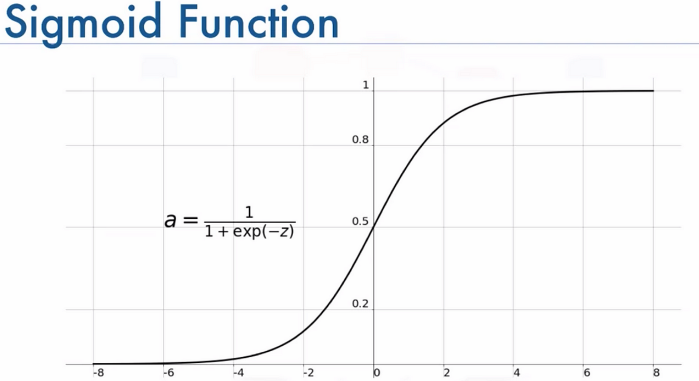

---

## Cost function for logistic regression

Recall that for logistic regression, the cost function is of the form 

$$ J(\mathbf{w},b) = \frac{1}{m} \sum_{i=0}^{m-1} \left[ loss(f_{\mathbf{w},b}(\mathbf{x}^{(i)}), y^{(i)}) \right] \tag{1}$$

where
* $loss(f_{\mathbf{w},b}(\mathbf{x}^{(i)}), y^{(i)})$ is the cost for a single data point, which is:

    $$loss(f_{\mathbf{w},b}(\mathbf{x}^{(i)}), y^{(i)}) = -y^{(i)} \log\left(f_{\mathbf{w},b}\left( \mathbf{x}^{(i)} \right) \right) - \left( 1 - y^{(i)}\right) \log \left( 1 - f_{\mathbf{w},b}\left( \mathbf{x}^{(i)} \right) \right) \tag{2}$$
    
*  where m is the number of training examples in the data set and:
$$
\begin{align}
  f_{\mathbf{w},b}(\mathbf{x^{(i)}}) &= g(z^{(i)})\tag{3} \\
  z^{(i)} &= \mathbf{w} \cdot \mathbf{x}^{(i)}+ b\tag{4} \\
  g(z^{(i)}) &= \frac{1}{1+e^{-z^{(i)}}}\tag{5} 
\end{align}
$$


---
# Gradient descent for logistic regression
Recall the gradient descent algorithm utilizes the gradient calculation:
$$\begin{align*}
&\text{repeat until convergence:} \; \lbrace \\
&  \; \; \;w_j = w_j -  \alpha \frac{\partial J(\mathbf{w},b)}{\partial w_j} \tag{1}  \; & \text{for j := 0..n-1} \\ 
&  \; \; \;  \; \;b = b -  \alpha \frac{\partial J(\mathbf{w},b)}{\partial b} \\
&\rbrace
\end{align*}$$

Where each iteration performs simultaneous updates on $w_j$ for all $j$, where
$$\begin{align*}
\frac{\partial J(\mathbf{w},b)}{\partial w_j}  &= \frac{1}{m} \sum\limits_{i = 0}^{m-1} (f_{\mathbf{w},b}(\mathbf{x}^{(i)}) - y^{(i)})x_{j}^{(i)} \tag{2} \\
\frac{\partial J(\mathbf{w},b)}{\partial b}  &= \frac{1}{m} \sum\limits_{i = 0}^{m-1} (f_{\mathbf{w},b}(\mathbf{x}^{(i)}) - y^{(i)}) \tag{3} 
\end{align*}$$

* m is the number of training examples in the data set      
* $f_{\mathbf{w},b}(x^{(i)})$ is the model's prediction, while $y^{(i)}$ is the target
* For a logistic regression model  
    $z = \mathbf{w} \cdot \mathbf{x} + b$  
    $f_{\mathbf{w},b}(x) = g(z)$  
    where $g(z)$ is the sigmoid function:  
    $g(z) = \frac{1}{1+e^{-z}}$   